In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("cibil_score.csv")

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 51336
Columns: 88


In [4]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
)

In [5]:
df = df.drop(
    columns=["unnamed: 0"],
    errors="ignore"
)

In [6]:
df.columns.tolist()

['prospectid',
 'total_tl',
 'tot_closed_tl',
 'tot_active_tl',
 'total_tl_opened_l6m',
 'tot_tl_closed_l6m',
 'pct_tl_open_l6m',
 'pct_tl_closed_l6m',
 'pct_active_tl',
 'pct_closed_tl',
 'total_tl_opened_l12m',
 'tot_tl_closed_l12m',
 'pct_tl_open_l12m',
 'pct_tl_closed_l12m',
 'tot_missed_pmnt',
 'auto_tl',
 'cc_tl',
 'consumer_tl',
 'gold_tl',
 'home_tl',
 'pl_tl',
 'secured_tl',
 'unsecured_tl',
 'other_tl',
 'age_oldest_tl',
 'age_newest_tl',
 'time_since_recent_payment',
 'time_since_first_deliquency',
 'time_since_recent_deliquency',
 'num_times_delinquent',
 'max_delinquency_level',
 'max_recent_level_of_deliq',
 'num_deliq_6mts',
 'num_deliq_12mts',
 'num_deliq_6_12mts',
 'max_deliq_6mts',
 'max_deliq_12mts',
 'num_times_30p_dpd',
 'num_times_60p_dpd',
 'num_std',
 'num_std_6mts',
 'num_std_12mts',
 'num_sub',
 'num_sub_6mts',
 'num_sub_12mts',
 'num_dbt',
 'num_dbt_6mts',
 'num_dbt_12mts',
 'num_lss',
 'num_lss_6mts',
 'num_lss_12mts',
 'recent_level_of_deliq',
 'tot_enq',
 

In [7]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [8]:
df = (
    df
    .drop_duplicates()
    .reset_index(drop=True)
)

In [9]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print(
    missing[
        missing > 0
    ]
)

Series([], dtype: int64)


In [10]:
missing_percentage = (
    df.isnull().mean() * 100
)

print(
    missing_percentage[
        missing_percentage > 0
    ]
    .sort_values(ascending=False)
)

Series([], dtype: float64)


In [11]:
numeric_df = df.select_dtypes(
    include=np.number
)

special_missing = (
    (numeric_df == -9999)
    .sum()
)

print(
    special_missing[
        special_missing > 0
    ]
)

Series([], dtype: int64)


In [12]:
print(
    df["approved_flag"]
    .value_counts()
)

approved_flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64


In [13]:
print(
    df["approved_flag"]
    .value_counts(
        normalize=True
    ) * 100
)

approved_flag
P2    62.722066
P3    14.516129
P4    11.457846
P1    11.303958
Name: proportion, dtype: float64


In [14]:
#Create binary target

df["target_binary"] = (
    df["approved_flag"]
    .map({
        "P1": 1,
        "P2": 1,
        "P3": 0,
        "P4": 0
    })
)

In [15]:
df[
    [
        "approved_flag",
        "target_binary"
    ]
].head(10)

,approved_flag,target_binary
0,P2,1
1,P2,1
2,P2,1
3,P2,1
4,P1,1
5,P3,0
6,P1,1
7,P2,1
8,P4,0
9,P1,1


In [16]:
print(
    df["target_binary"]
    .value_counts()
)

target_binary
1    38002
0    13334
Name: count, dtype: int64


In [17]:
print(
    df["target_binary"]
    .value_counts(
        normalize=True
    ) * 100
)

target_binary
1    74.026025
0    25.973975
Name: proportion, dtype: float64


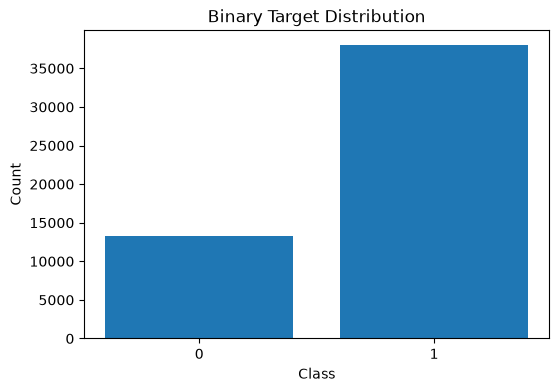

In [18]:
class_counts = (
    df["target_binary"]
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(6, 4)
)

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.xlabel("Class")
plt.ylabel("Count")

plt.title(
    "Binary Target Distribution"
)

plt.show()

In [19]:
X = df.drop(
    columns=[
        "approved_flag",
        "target_binary",
        "credit_score",
        "prospectid"
    ],
    errors="ignore"
)

y = df["target_binary"]

In [20]:
print(
    "Missing target:",
    y.isnull().sum()
)

Missing target: 0


In [21]:
X = X.reset_index(
    drop=True
)

y = y.reset_index(
    drop=True
)

In [22]:
#Identify numerical and categorical features
numeric_features = (
    X.select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

In [23]:
print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "\nCategorical columns:"
)

print(
    categorical_features
)

Numerical features: 79
Categorical features: 5

Categorical columns:
['maritalstatus', 'education', 'gender', 'last_prod_enq2', 'first_prod_enq2']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
print(
    "Training distribution:"
)

print(
    y_train.value_counts(
        normalize=True
    )
)

print(
    "\nTesting distribution:"
)

print(
    y_test.value_counts(
        normalize=True
    )
)

Training distribution:
target_binary
1    0.74026
0    0.25974
Name: proportion, dtype: float64

Testing distribution:
target_binary
1    0.740261
0    0.259739
Name: proportion, dtype: float64


In [26]:
#Numerical preprocessing
#For XGBoost, scaling is not required.

#We only need missing-value treatment:

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [27]:
#Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [28]:
#Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [29]:
#Basic XGBoost Binary Classifier

#Start with a basic model:

xgb_basic = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,

    random_state=42,
    n_jobs=-1
)

In [30]:
xgb_basic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            xgb_basic
        )
    ]
)

In [31]:
xgb_basic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](84,)","['total_tl','tot_closed_tl','tot_active_tl',...,'gl_flag','last_prod_enq2', 'first_prod_enq2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,84
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [33]:
#Make predictions

#Class predictions:

y_pred_basic = (
    xgb_basic_pipeline
    .predict(
        X_test
    )

)

In [34]:
y_prob_basic = (
    xgb_basic_pipeline
    .predict_proba(
        X_test
    )[:, 1]
)

In [37]:
accuracy_basic = accuracy_score(
    y_test,
    y_pred_basic
)

precision_basic = precision_score(
    y_test,
    y_pred_basic
)

recall_basic = recall_score(
    y_test,
    y_pred_basic
)

f1_basic = f1_score(
    y_test,
    y_pred_basic
)

auc_basic = roc_auc_score(
    y_test,
    y_prob_basic
)

In [38]:
print(
    "Basic XGBoost Binary Classifier"
)

print(
    "Accuracy :",
    accuracy_basic
)

print(
    "Precision:",
    precision_basic
)

print(
    "Recall   :",
    recall_basic
)

print(
    "F1 Score :",
    f1_basic
)

print(
    "ROC-AUC  :",
    auc_basic
)

Basic XGBoost Binary Classifier
Accuracy : 0.8856641994546163
Precision: 0.9017377172146518
Recall   : 0.9489540849888173
F1 Score : 0.9247435897435897
ROC-AUC  : 0.9372745490092255


In [39]:
cm_basic = confusion_matrix(
    y_test,
    y_pred_basic
)

print(
    "Confusion Matrix:"
)

print(
    cm_basic
)

Confusion Matrix:
[[1881  786]
 [ 388 7213]]


In [40]:
print(
    classification_report(
        y_test,
        y_pred_basic
    )
)

              precision    recall  f1-score   support

           0       0.83      0.71      0.76      2667
           1       0.90      0.95      0.92      7601

    accuracy                           0.89     10268
   macro avg       0.87      0.83      0.84     10268
weighted avg       0.88      0.89      0.88     10268



In [41]:
train_pred_basic = (
    xgb_basic_pipeline
    .predict(
        X_train
    )
)

train_accuracy_basic = accuracy_score(
    y_train,
    train_pred_basic
)

print(
    "Training Accuracy:",
    train_accuracy_basic
)

print(
    "Testing Accuracy:",
    accuracy_basic
)

Training Accuracy: 0.9203516119606506
Testing Accuracy: 0.8856641994546163


In [42]:
xgb_regularized = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=3,

    gamma=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.1,

    reg_lambda=1.0,

    random_state=42,

    n_jobs=-1
)

In [43]:
xgb_reg_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            xgb_regularized
        )
    ]
)

In [44]:
xgb_reg_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](84,)","['total_tl','tot_closed_tl','tot_active_tl',...,'gl_flag','last_prod_enq2', 'first_prod_enq2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,84
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [45]:
y_pred_reg = (
    xgb_reg_pipeline
    .predict(
        X_test
    )
)

y_prob_reg = (
    xgb_reg_pipeline
    .predict_proba(
        X_test
    )[:, 1]
)

In [46]:
accuracy_reg = accuracy_score(
    y_test,
    y_pred_reg
)

precision_reg = precision_score(
    y_test,
    y_pred_reg
)

recall_reg = recall_score(
    y_test,
    y_pred_reg
)

f1_reg = f1_score(
    y_test,
    y_pred_reg
)

auc_reg = roc_auc_score(
    y_test,
    y_prob_reg
)

In [47]:
print(
    "Regularized XGBoost Binary Classifier"
)

print(
    "Accuracy :",
    accuracy_reg
)

print(
    "Precision:",
    precision_reg
)

print(
    "Recall   :",
    recall_reg
)

print(
    "F1 Score :",
    f1_reg
)

print(
    "ROC-AUC  :",
    auc_reg
)

Regularized XGBoost Binary Classifier
Accuracy : 0.8851772497078302
Precision: 0.9028858218318695
Recall   : 0.9467175371661624
F1 Score : 0.9242823196968724
ROC-AUC  : 0.9358475714151044


In [48]:
cm_reg = confusion_matrix(
    y_test,
    y_pred_reg
)

print(
    cm_reg
)

[[1893  774]
 [ 405 7196]]


In [49]:
print(
    classification_report(
        y_test,
        y_pred_reg
    )
)

              precision    recall  f1-score   support

           0       0.82      0.71      0.76      2667
           1       0.90      0.95      0.92      7601

    accuracy                           0.89     10268
   macro avg       0.86      0.83      0.84     10268
weighted avg       0.88      0.89      0.88     10268



In [50]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Basic XGBoost",
            "Regularized XGBoost"
        ],

        "Accuracy": [
            accuracy_basic,
            accuracy_reg
        ],

        "Precision": [
            precision_basic,
            precision_reg
        ],

        "Recall": [
            recall_basic,
            recall_reg
        ],

        "F1": [
            f1_basic,
            f1_reg
        ],

        "ROC-AUC": [
            auc_basic,
            auc_reg
        ]
    }
)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Basic XGBoost,0.885664,0.901738,0.948954,0.924744,0.937275
1,Regularized XGBoost,0.885177,0.902886,0.946718,0.924282,0.935848


In [51]:
train_pred_reg = (
    xgb_reg_pipeline
    .predict(
        X_train
    )
)

train_accuracy_reg = accuracy_score(
    y_train,
    train_pred_reg
)

In [52]:
print(
    "Basic XGBoost"
)

print(
    "Train Accuracy:",
    train_accuracy_basic
)

print(
    "Test Accuracy :",
    accuracy_basic
)

print()

print(
    "Regularized XGBoost"
)

print(
    "Train Accuracy:",
    train_accuracy_reg
)

print(
    "Test Accuracy :",
    accuracy_reg
)

Basic XGBoost
Train Accuracy: 0.9203516119606506
Test Accuracy : 0.8856641994546163

Regularized XGBoost
Train Accuracy: 0.9121457095548846
Test Accuracy : 0.8851772497078302


In [53]:
print(
    "Basic Train-Test Gap:",
    train_accuracy_basic - accuracy_basic
)

print(
    "Regularized Train-Test Gap:",
    train_accuracy_reg - accuracy_reg
)

Basic Train-Test Gap: 0.034687412506034354
Regularized Train-Test Gap: 0.026968459847054427


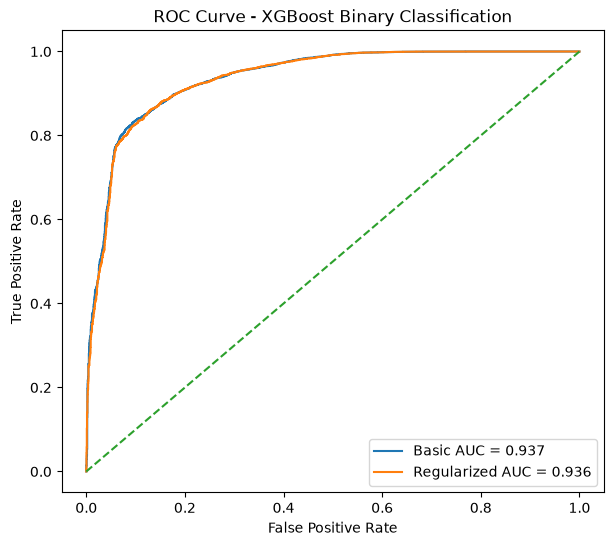

In [54]:
fpr_basic, tpr_basic, _ = roc_curve(
    y_test,
    y_prob_basic
)

fpr_reg, tpr_reg, _ = roc_curve(
    y_test,
    y_prob_reg
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    fpr_basic,
    tpr_basic,
    label=f"Basic AUC = {auc_basic:.3f}"
)

plt.plot(
    fpr_reg,
    tpr_reg,
    label=f"Regularized AUC = {auc_reg:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - XGBoost Binary Classification"
)

plt.legend()

plt.show()

In [55]:
fitted_preprocessor = (
    xgb_reg_pipeline
    .named_steps[
        "preprocessor"
    ]
)

In [56]:
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

In [57]:
fitted_model = (
    xgb_reg_pipeline
    .named_steps[
        "model"
    ]
)

In [58]:
importance = (
    fitted_model
    .feature_importances_
)

In [59]:
feature_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": importance
    }
)

In [60]:
feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
61,num__enq_l3m,0.146847
74,num__pct_pl_enq_l6m_of_ever,0.072433
60,num__enq_l6m,0.065097
27,num__time_since_recent_deliquency,0.051473
56,num__pl_enq_l6m,0.039651
26,num__time_since_first_deliquency,0.036683
23,num__age_oldest_tl,0.032327
40,num__num_std_12mts,0.031834
72,num__pct_pl_enq_l6m_of_l12m,0.029774
28,num__num_times_delinquent,0.027279


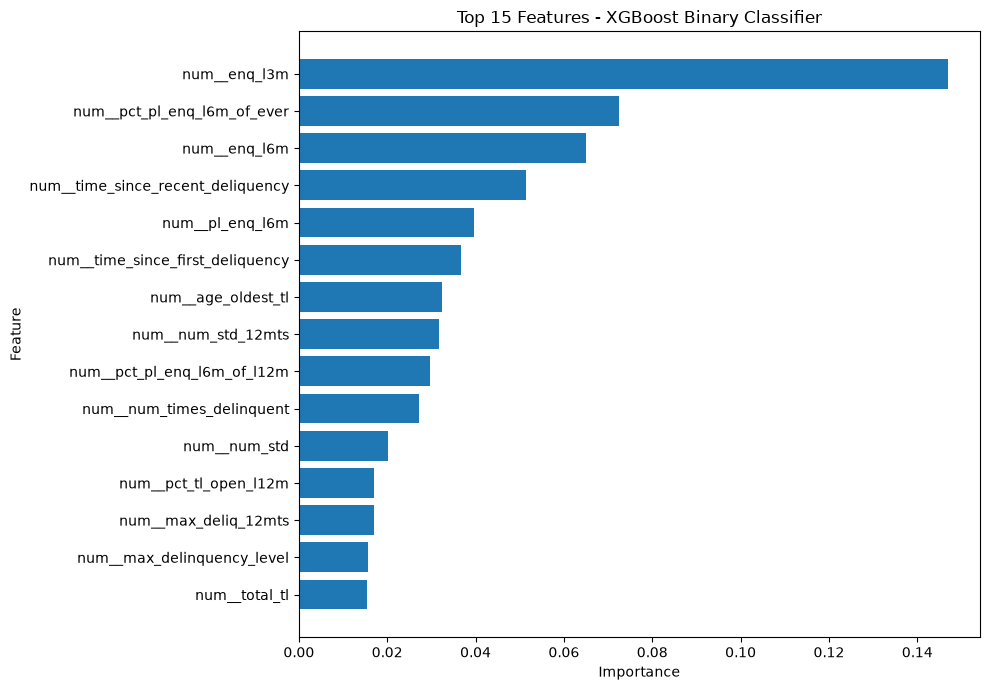

In [61]:
top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "Importance"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Features - XGBoost Binary Classifier"
)

plt.tight_layout()

plt.show()

In [62]:
negative = (
    y_train == 0
).sum()

positive = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative / positive
)

print(
    "Class 0:",
    negative
)

print(
    "Class 1:",
    positive
)

print(
    "scale_pos_weight:",
    scale_pos_weight
)

Class 0: 10667
Class 1: 30401
scale_pos_weight: 0.3508766159007927


XGBoost Binary Classification uses sequential decision trees to predict one of two classes.
Each new tree attempts to correct errors made by the earlier trees. 
We use binary:logistic so the model produces a probability for class 1. 
Regularization parameters such as reg_alpha, reg_lambda, max_depth, gamma, min_child_weight, subsample, and colsample_bytree reduce unnecessary model complexity and help prevent overfitting.
We evaluate the model using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, and the difference between training and testing performance.